# Cell typing – updated to match IHOPE project

# Prep

In [1]:
import pandas as pd
from anndata import AnnData, read_h5ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Make sure you're in the parent directory:

In [4]:
import sys
from pathlib import Path
#TODO try to remove this somehow
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

If you already have a H5AD file with an anndata object:

In [55]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

basename = "IHOPE14_MedLN_BottomLeft"

# Read file and create AnnData object
filename = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"
adata = load_and_build_anndata(filename)

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/anndata_helpers.py:76: DtypeWarning: Columns (14,15,19,20,24,25,29,30,34,35,39,40,44,45,49,50,54,55,59,60,64,65,69,70,73,74,75,78,79,80,84,85,89,90,94,95,99,100,104,105,109,110,114,115,119,120,124,125,129,130,134,135,139,140,144,145,149,150,154,155,159,160,164,165,168,169,170,174,175,179,180,184,185,189,190,194,195,199,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dropping 19267 rows with NaN in 'Nucleus/Cell area ratio'


# Preprocessing

**If it's the first time running the sample:**

Load, filter and normalize your raw data in csv format. Also, make sure to specify which file you're working with to facilitate later analysis. All subsequent naming of files is based on this.

In [4]:
from scripts import preprocessing
import importlib

# Reload to ensure notebook uses the latest version of the script
importlib.reload(preprocessing)

# Input path, here you need to write the entire raw data file name
csv_in = "../data/raw/IHOPE14_MedLN_BottomLeft.csv"

# Keep track of which sample you're working on:
basename = "IHOPE14_MedLN_BottomLeft"

# Output path, you can use this default format based on your basename:
csv_out = f"../data/processed/{basename}_cleaned_raw.csv"

# Clean raw CSV
preprocessing.clean_cell_columns(csv_in, csv_out)

Created directory: ../data/processed
Cleaned CSV saved to: ../data/processed/IHOPE14_MedLN_BottomLeft_cleaned_raw.csv


/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/preprocessing.py:84: DtypeWarning: Columns (14,15,19,20,24,25,29,30,34,35,39,40,44,45,49,50,54,55,59,60,64,65,69,70,73,74,75,78,79,80,84,85,89,90,94,95,99,100,104,105,109,110,114,115,119,120,124,125,129,130,134,135,139,140,144,145,149,150,154,155,159,160,164,165,168,169,170,174,175,179,180,184,185,189,190,194,195,199,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file, encoding="utf-8")


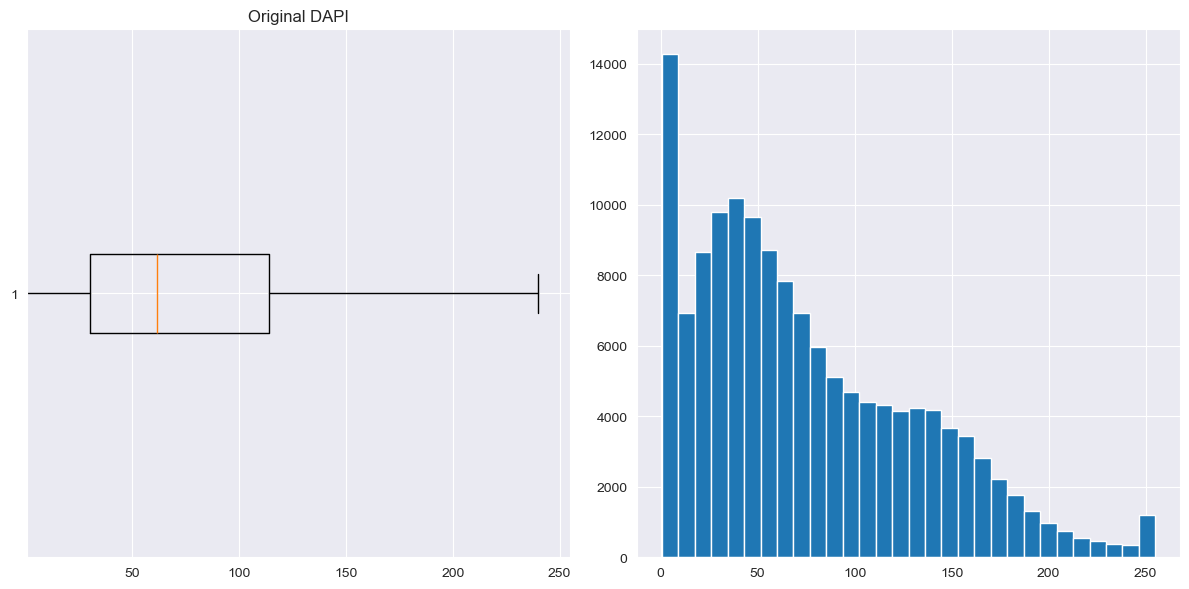

Filtered data saved to: ../data/processed/IHOPE14_MedLN_BottomLeft_cleaned_filtered.csv


In [5]:
from scripts import preprocessing
import importlib

# Reload to ensure the latest version of the script is used
importlib.reload(preprocessing)

# Run preprocessing
input_file = f"../data/processed/{basename}_cleaned_raw.csv"
output_file = f"../data/processed/{basename}_cleaned_filtered.csv"

preprocessing.preprocess(input_file, output_file, plot=True)


**Normalize**

Choose between: "arcsinh", "z-score" and "none".

For arcsinh, you can specify a cofactor.

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/transforms.py:117: DtypeWarning: Columns (14,15,19,20,24,25,29,30,34,35,39,40,44,45,49,50,54,55,59,60,64,65,69,70,73,74,75,78,79,80,84,85,89,90,94,95,99,100,104,105,109,110,114,115,119,120,124,125,129,130,134,135,139,140,144,145,149,150,154,155,159,160,164,165,168,169,170,174,175,179,180,184,185,189,190,194,195,199,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Saved CSV to: ../data/processed/IHOPE14_MedLN_BottomLeft_cleaned_filtered_arcsinh_cf5.0.csv
Plot saved to: ../results/figures/IHOPE14_MedLN_BottomLeft_cleaned_filtered_arcsinh_cf5.0_distributions.png


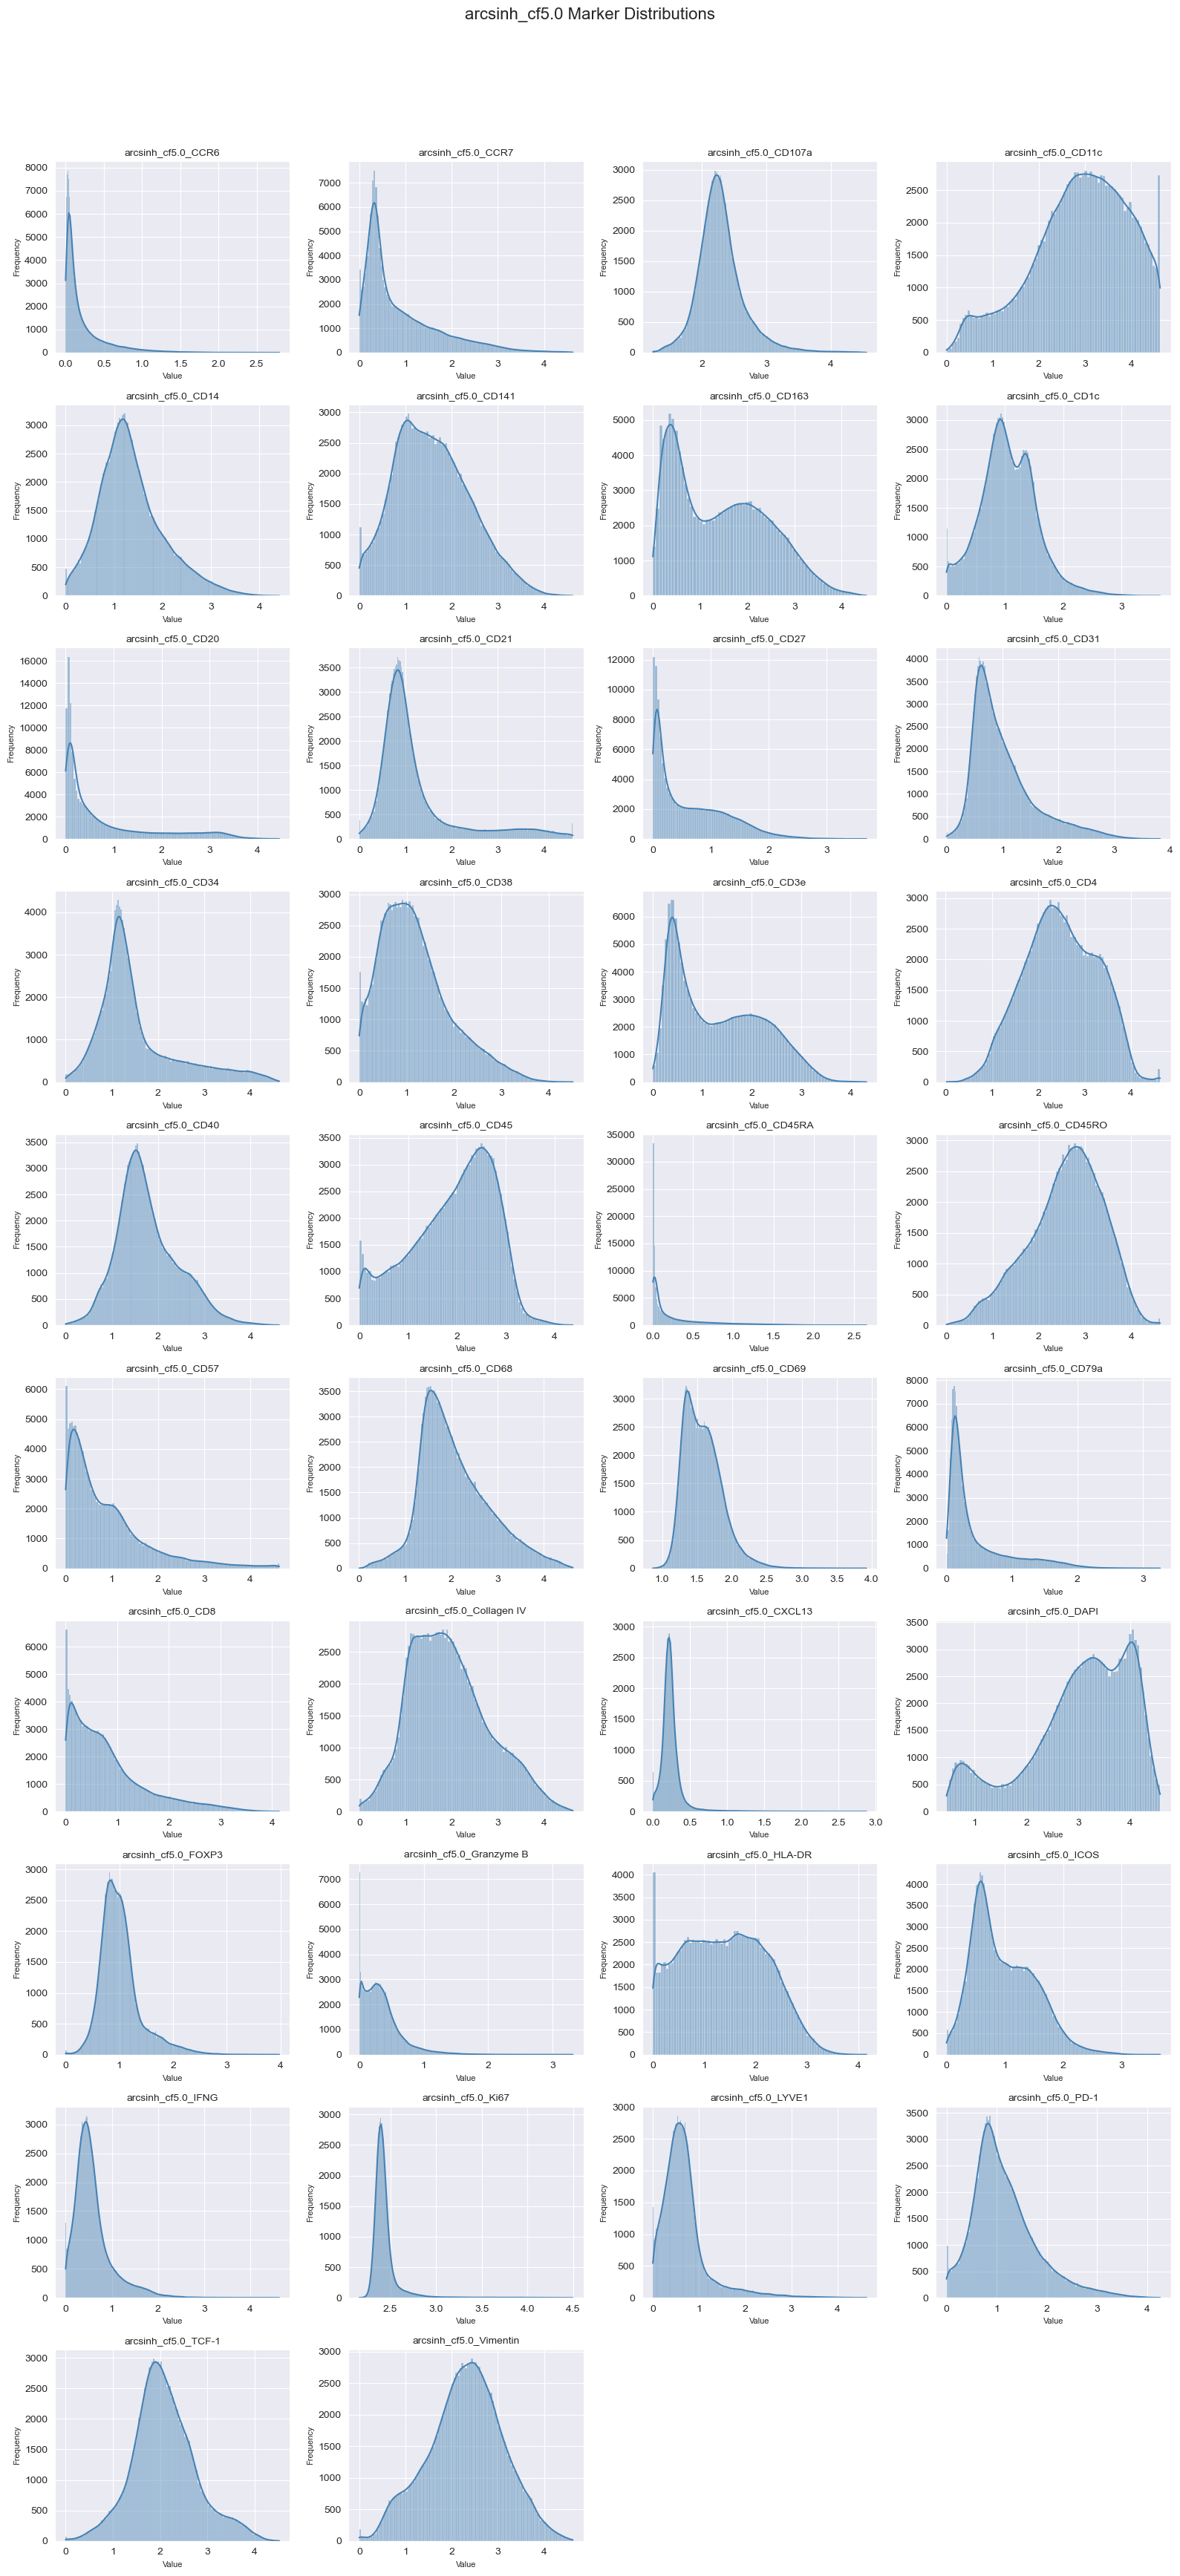

In [6]:
from scripts.transforms import apply_transform

method = "arcsinh"
cofactor = 5.0    # Comment out if not applying arcsinh
input_file = f"../data/processed/{basename}_cleaned_filtered.csv"
output_file = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"

df_out, markers, metadata, fig = apply_transform(
    input_file=input_file,
    method=method,
    cofactor=cofactor, # Comment out if not applying arcsinh
    output_file=output_file,
    save_plot=True
)

# Building Anndata and annotating marker positivity


In [4]:
import importlib
import scripts.anndata_helpers

# Reload the module after editing
importlib.reload(scripts.anndata_helpers)

<module 'scripts.anndata_helpers' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/anndata_helpers.py'>

In [7]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

# Read file and create AnnData object
filename = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"
adata = load_and_build_anndata(filename)

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/anndata_helpers.py:76: DtypeWarning: Columns (14,15,19,20,24,25,29,30,34,35,39,40,44,45,49,50,54,55,59,60,64,65,69,70,73,74,75,78,79,80,84,85,89,90,94,95,99,100,104,105,109,110,114,115,119,120,124,125,129,130,134,135,139,140,144,145,149,150,154,155,159,160,164,165,168,169,170,174,175,179,180,184,185,189,190,194,195,199,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dropping 19267 rows with NaN in 'Nucleus/Cell area ratio'


In [8]:
print("adata summary: ")
print(adata)
print("adata X shape: ")
print(adata.X.shape)
print("adata spatial data dimensions: ")
print(adata.obsm['spatial'].shape)
print("adata var: ")
print(adata.var)
print("adata var names: ")
print(adata.var_names)

adata summary: 
AnnData object with n_obs × n_vars = 112174 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y'
    obsm: 'spatial'
adata X shape: 
(112174, 38)
adata spatial data dimensions: 
(112174, 2)
adata var: 
Empty DataFrame
Columns: []
Index: [arcsinh_cf5.0_CCR6, arcsinh_cf5.0_CCR7, arcsinh_cf5.0_CD107a, arcsinh_cf5.0_CD11c, arcsinh_cf5.0_CD14, arcsinh_cf5.0_CD141, arcsinh_cf5.0_CD163, arcsinh_cf5.0_CD1c, arcsinh_cf5.0_CD20, arcsinh_cf5.0_CD21, arcsinh_cf5.0_CD27, arcsinh_cf5.0_CD31, arcsinh_cf5.0_CD34, arcsinh_cf5.0_CD38, arcsinh_cf5.0_CD3e, arcsinh_cf5.0_CD4, arcsinh_cf5.0_CD40, arcsinh_cf5.0_CD45, arcsinh_cf5.0_CD45RA, arcsinh_cf5.0_CD45RO, arcsinh_cf5.0_CD57, arcsinh_cf5.0_CD68, arcsinh_cf5.0_CD69, arcsinh_cf5.0_CD79a, arcsinh_cf5.0_CD8, arcsinh_cf5.0_Collagen IV, arcsinh_cf5.0_CXCL13, arcsinh_cf5.0_DAPI, arcsinh_cf5.0_FOXP3, arcsinh_cf5.0_Granzyme B, arcsinh_cf5.0_HLA-DR, arcsinh_cf5.0_ICOS, arcsinh_cf5.0_IFNG, arc

Apply marker positivity thresholds (GMM intersections):

In [56]:
from scripts.annotation import compute_positivity_matrix

# Annotate all cells with GMM-based positivity for canonical markers, fallback to percentile if unimodal
adata, thresholds, best_gmms = compute_positivity_matrix(
    adata,
    quantile=0.8,
    random_state=0
)

Added 38 _pos columns to adata.obs
Unimodal markers: []
Bimodal markers: ['CCR6', 'CCR7', 'CD107a', 'CD11c', 'CD14', 'CD141', 'CD163', 'CD1c', 'CD20', 'CD21', 'CD27', 'CD31', 'CD34', 'CD38', 'CD3e', 'CD4', 'CD40', 'CD45', 'CD45RA', 'CD45RO', 'CD57', 'CD68', 'CD69', 'CD79a', 'CD8', 'Collagen IV', 'CXCL13', 'DAPI', 'FOXP3', 'Granzyme B', 'HLA-DR', 'ICOS', 'IFNG', 'Ki67', 'LYVE1', 'PD-1', 'TCF-1', 'Vimentin']


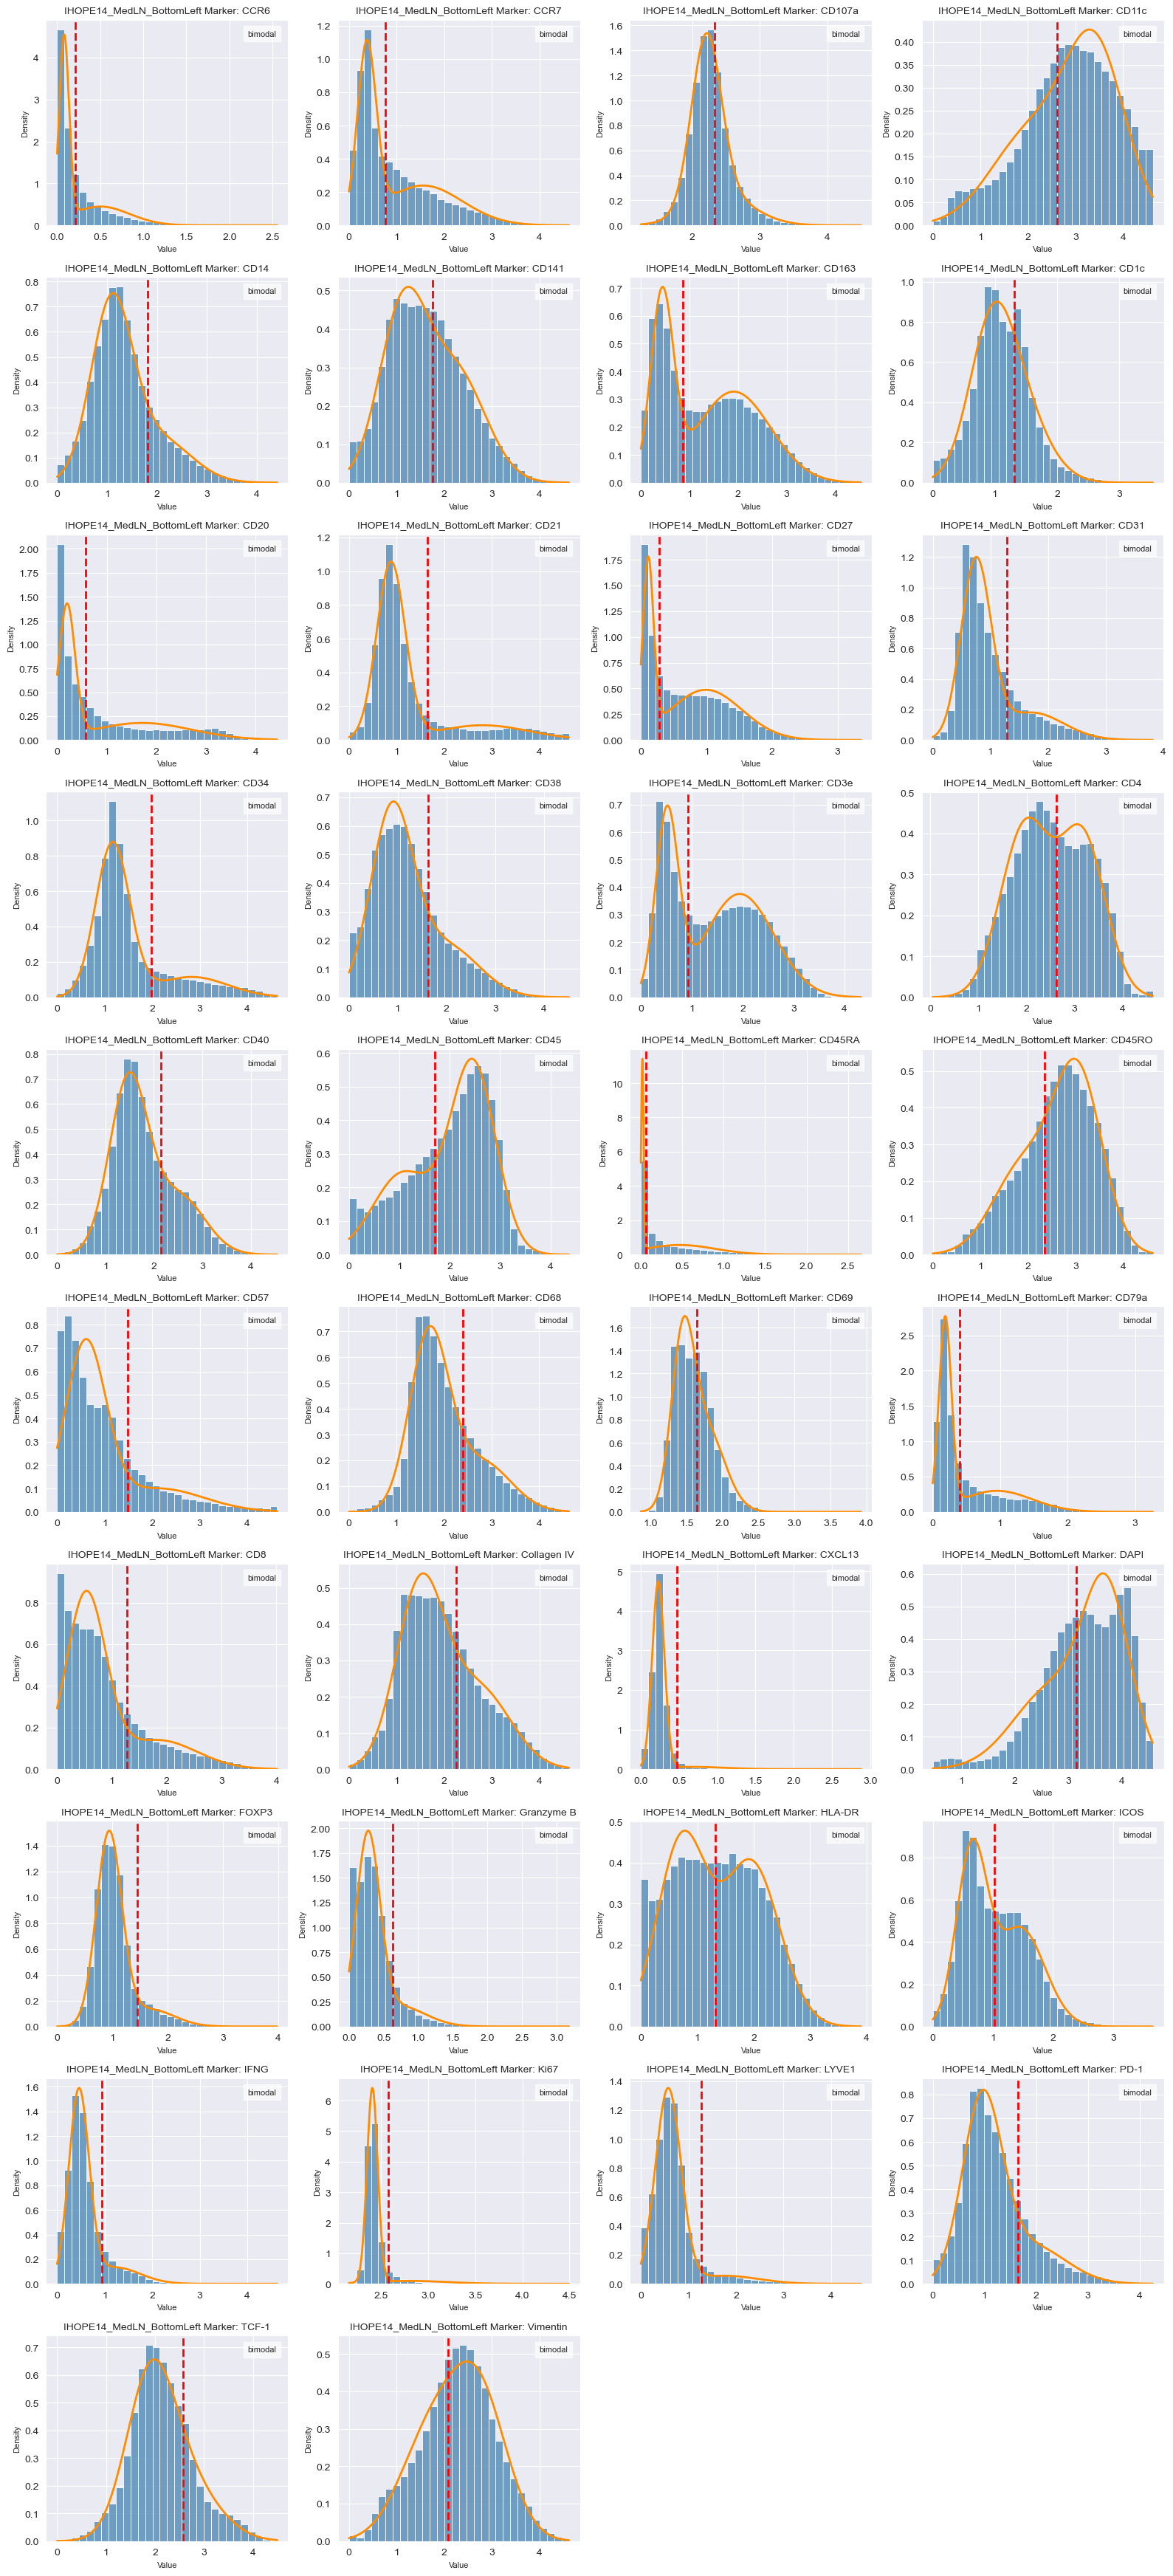

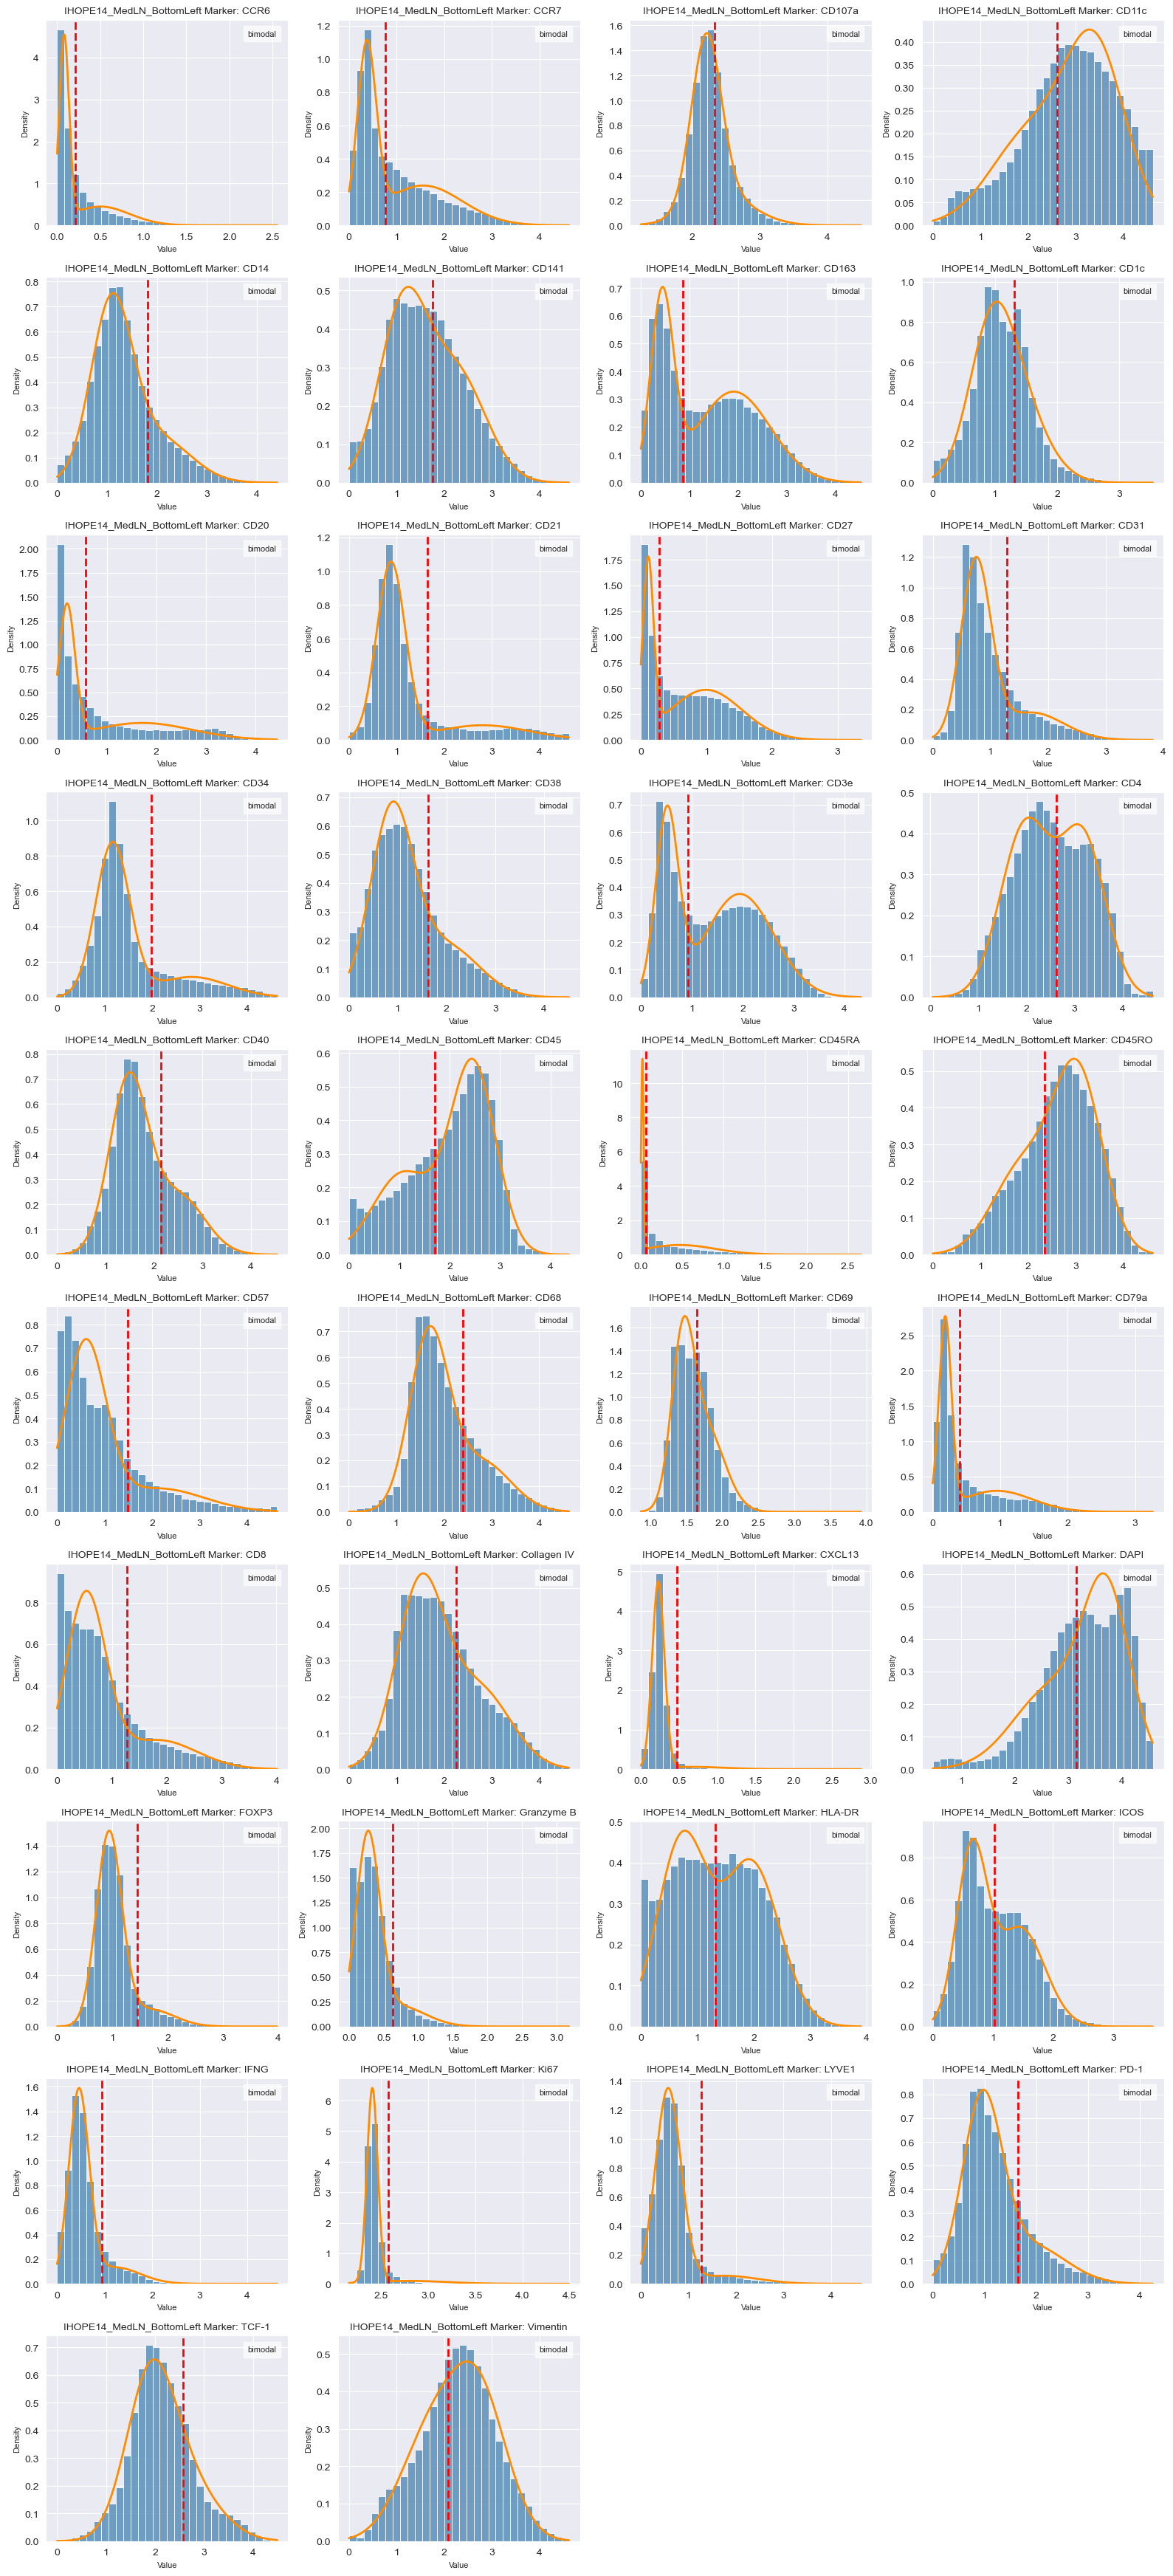

In [57]:
# Visualize the distributions and thresholds:
from scripts.annotation import plot_marker_gmm_adata
plot_marker_gmm_adata(adata,
                      thresholds,
                      best_gmms,
                      title_prefix=f"{basename} Marker: ",
                      save=False,
                      filename="GMM_histograms")

Optional: add high/low levels to marker of interest.

Specify marker name, quantiles to label as low and high, and a recommended plot for visualization.

In [9]:
import importlib
import scripts.annotation

# Reload the module after editing
importlib.reload(scripts.annotation)

<module 'scripts.annotation' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/annotation.py'>


CD38 intensity tiers (restricted to CD38_pos cells)
  low_q  = 0.33  -> threshold = 1.9084
  high_q = 0.90 -> threshold = 2.9769
Counts:
  total cells:   112174
  CD38_pos:  27548
  CD38_low:  9091  (33.0%)
  CD38_mid:  15702  (57.0%)
  CD38_high: 2755  (10.0%)


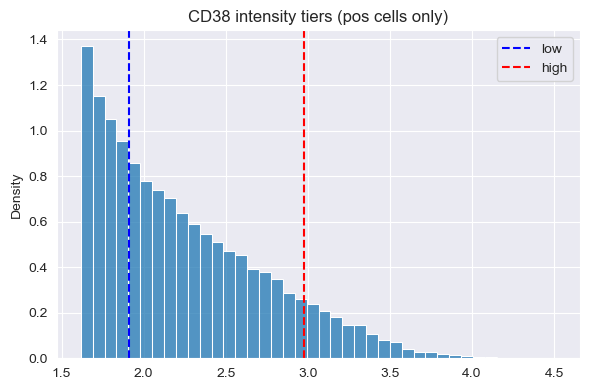

AnnData object with n_obs × n_vars = 112174 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 'CD40_pos', 'CD45_pos', 'CD45RA_pos', 'CD45RO_pos', 'CD57_pos', 'CD68_pos', 'CD69_pos', 'CD79a_pos', 'CD8_pos', 'Collagen IV_pos', 'CXCL13_pos', 'DAPI_pos', 'FOXP3_pos', 'Granzyme B_pos', 'HLA-DR_pos', 'ICOS_pos', 'IFNG_pos', 'Ki67_pos', 'LYVE1_pos', 'PD-1_pos', 'TCF-1_pos', 'Vimentin_pos', 'CD38_low', 'CD38_mid', 'CD38_high'
    uns: 'thresholds', 'intensity_thresholds'
    obsm: 'spatial'

In [11]:
from scripts import annotation

annotation.add_intensity_tiers(
    adata,
    marker="CD38",
    low_q=0.33,
    high_q=0.9,
    plot=True
)


CD21 intensity tiers (restricted to CD21_pos cells)
  low_q  = 0.33  -> threshold = 2.3729
  high_q = 0.90 -> threshold = 4.1319
Counts:
  total cells:   112174
  CD21_pos:  22094
  CD21_low:  7291  (33.0%)
  CD21_mid:  12593  (57.0%)
  CD21_high: 2210  (10.0%)


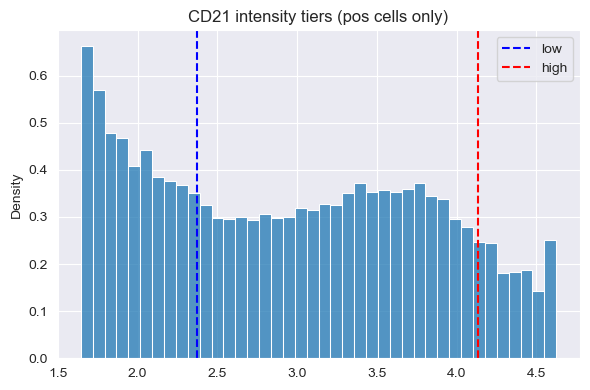

AnnData object with n_obs × n_vars = 112174 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 'CD40_pos', 'CD45_pos', 'CD45RA_pos', 'CD45RO_pos', 'CD57_pos', 'CD68_pos', 'CD69_pos', 'CD79a_pos', 'CD8_pos', 'Collagen IV_pos', 'CXCL13_pos', 'DAPI_pos', 'FOXP3_pos', 'Granzyme B_pos', 'HLA-DR_pos', 'ICOS_pos', 'IFNG_pos', 'Ki67_pos', 'LYVE1_pos', 'PD-1_pos', 'TCF-1_pos', 'Vimentin_pos', 'CD38_low', 'CD38_mid', 'CD38_high', 'CD21_low', 'CD21_mid', 'CD21_high'
    uns: 'thresholds', 'intensity_thresholds'
    obsm: 'spatial'

In [12]:
from scripts import annotation

annotation.add_intensity_tiers(
    adata,
    marker="CD21",
    low_q=0.33,
    high_q=0.9,
    plot=True
)

Save anndata object with progress so far

In [58]:
# Save AnnData as h5ad
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
save_h5ad(adata, h5adpath)

To load the same anndata:

In [48]:
import anndata as ad

adata = ad.read_h5ad(
    f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
)

# Rule-based cell typing

Each cell type will correspond to a column in the AnnData object, with a boolean True/False for every cell type in every cell.

If you want to clean up before you rerun cell type assignment:

In [59]:
import scripts
import scripts.celltype_rules_IHOPE
import importlib

importlib.reload(scripts.celltype_rules_IHOPE)

<module 'scripts.celltype_rules_IHOPE' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/celltype_rules_IHOPE.py'>

In [230]:
#If you need to load anndata:

import anndata as ad

basename = ""
adata = ad.read_h5ad(
    f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
)

In [60]:
from scripts.celltype_rules_IHOPE import assign_cell_types_bool_IHOPE

adata = assign_cell_types_bool_IHOPE(adata)


Total cells: 112174

Level 1 — Lineage (type):
  type_B: 2747 (2.4%)
  type_T: 22530 (20.1%)
  type_NK: 152 (0.1%)
  type_unclassified: 86761 (77.3%)

Level 2 — Intermediate states:
  T cells:
    intermediate_CD4_T: 11953 (10.7% of total, 53.1% of T)
    intermediate_CD8_T: 3865 (3.4% of total, 17.2% of T)
    intermediate_T_naive: 669 (0.6% of total, 3.0% of T)
    intermediate_T_memory: 21861 (19.5% of total, 97.0% of T)
  B cells:
    intermediate_B_naive: 113 (0.1% of total, 4.1% of B)
    intermediate_B_memory: 1081 (1.0% of total, 39.4% of B)

Level 3 — Subtypes:
  B cell subtypes:
    subtype_B_GC: 655 (0.6% of total, 23.8% of B)
    subtype_B_plasmablast: 657 (0.6% of total, 23.9% of B)
    subtype_B_unassigned: 1995 (1.8% of total, 72.6% of B)
  T cell subtypes:
    subtype_TN_CD4: 507 (0.5% of total, 2.3% of T)
    subtype_TN_CD8: 41 (0.0% of total, 0.2% of T)
    subtype_TCM_CD4: 7338 (6.5% of total, 32.6% of T)
    subtype_TCM_CD8: 438 (0.4% of total, 1.9% of T)
    subtyp

Save anndata with cell type information:

In [61]:
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes.h5ad"
save_h5ad(adata, h5adpath)

# Visual diagnostics

Some FACS-style plots to "diagnose" how the thresholds look:

In [44]:
import scripts
import scripts.marker_plots
import importlib

importlib.reload(scripts.marker_plots)

<module 'scripts.marker_plots' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/marker_plots.py'>

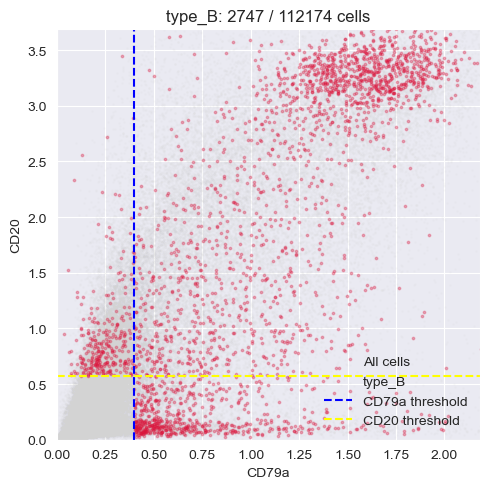

In [67]:
from scripts.marker_plots import plot_marker_axes

plot_marker_axes(
    adata,
    x_marker="CD79a",
    y_marker="CD20",
    base_mask="type_B",
    title=f"B cells: CD45 vs CD20",
    show_thresholds = True
)

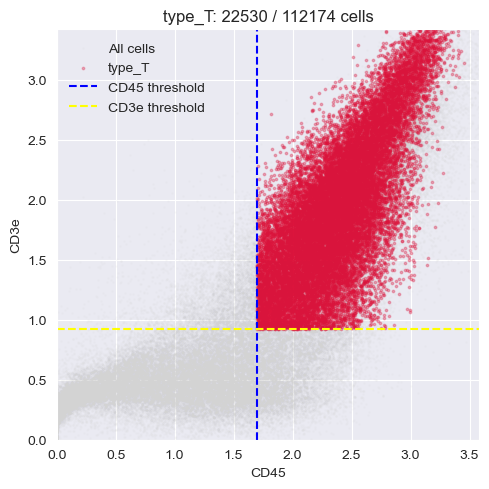

In [66]:
plot_marker_axes(
    adata,
    x_marker="CD45",
    y_marker="CD3e",
    base_mask="type_T",
    title="T cells: CD45 vs CD3e"
)

Marker spatial plots:

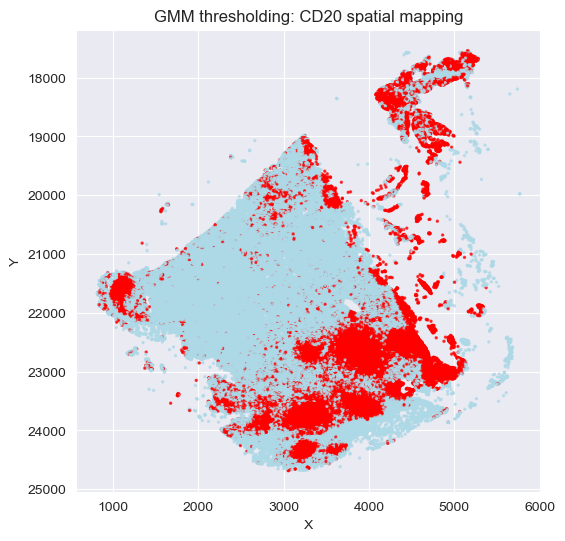

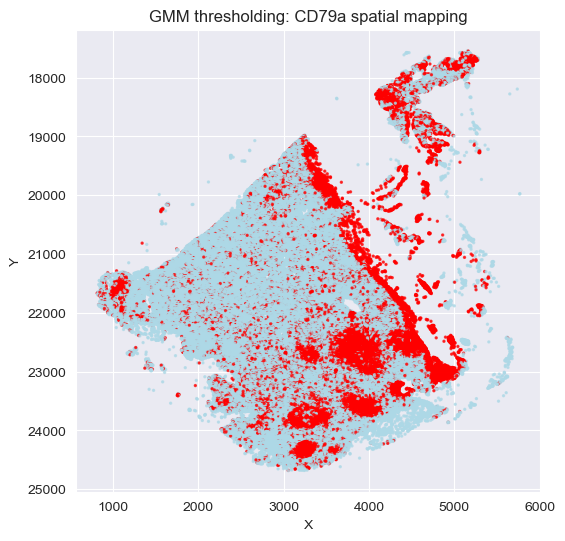

In [68]:
import scripts
from scripts.spatialmapping import plot_spatial_marker

# One marker
plot_spatial_marker(adata, "CD20", thresholded=True, title_prefix="GMM thresholding: ", color_hi="red", color_lo="lightblue")

plot_spatial_marker(adata, "CD79a", thresholded=True, title_prefix="GMM thresholding: ", color_hi="red", color_lo="lightblue")


Heatmap of markers in cell types:

In [147]:
import scripts
import scripts.plotting
import scripts.spatial_plot
import importlib

importlib.reload(scripts.plotting)
importlib.reload(scripts.spatial_plot)


<module 'scripts.spatial_plot' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/spatial_plot.py'>

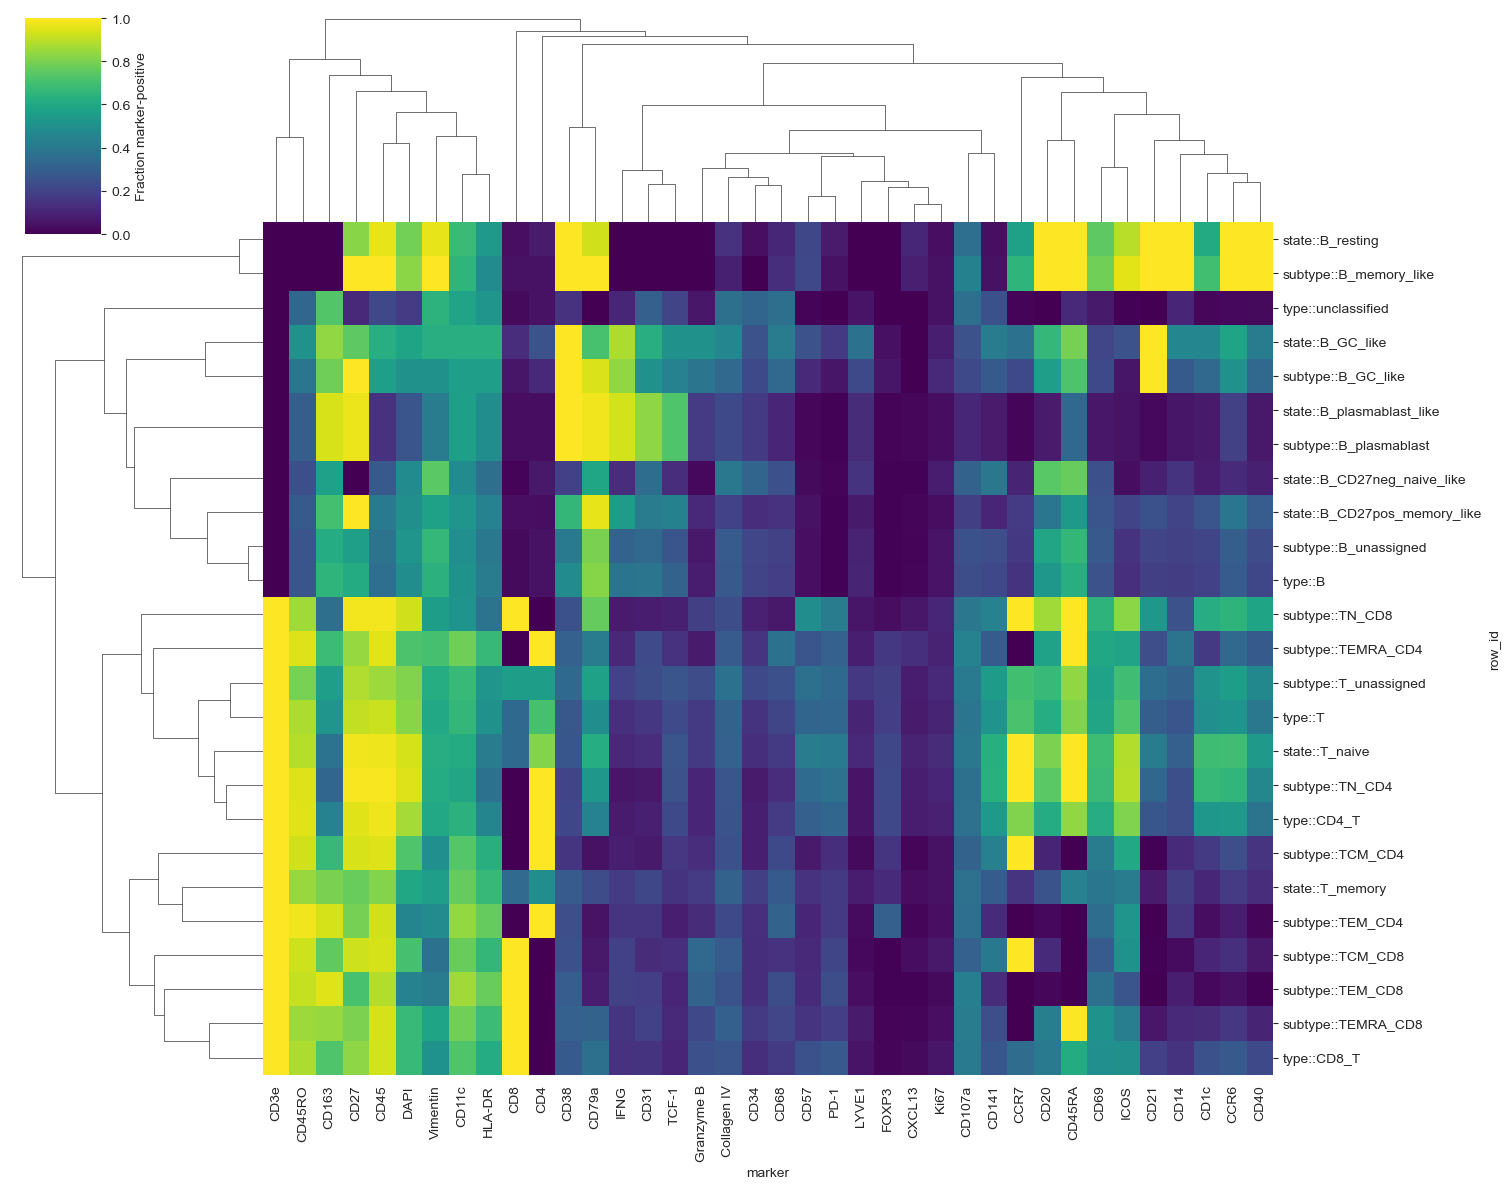

In [18]:
from scripts.plotting import clustered_marker_heatmap

# all cell type columns
celltype_cols = [
    c for c in adata.obs.columns
    if c.startswith(("type_", "state_", "subtype_"))
]

matrix = clustered_marker_heatmap(
    adata,
    celltype_cols=celltype_cols,
    min_cells=15,
    base_fig_width=10,
    fig_height=12,
    cmap="viridis",
)


Quick spatial type/subtype plot

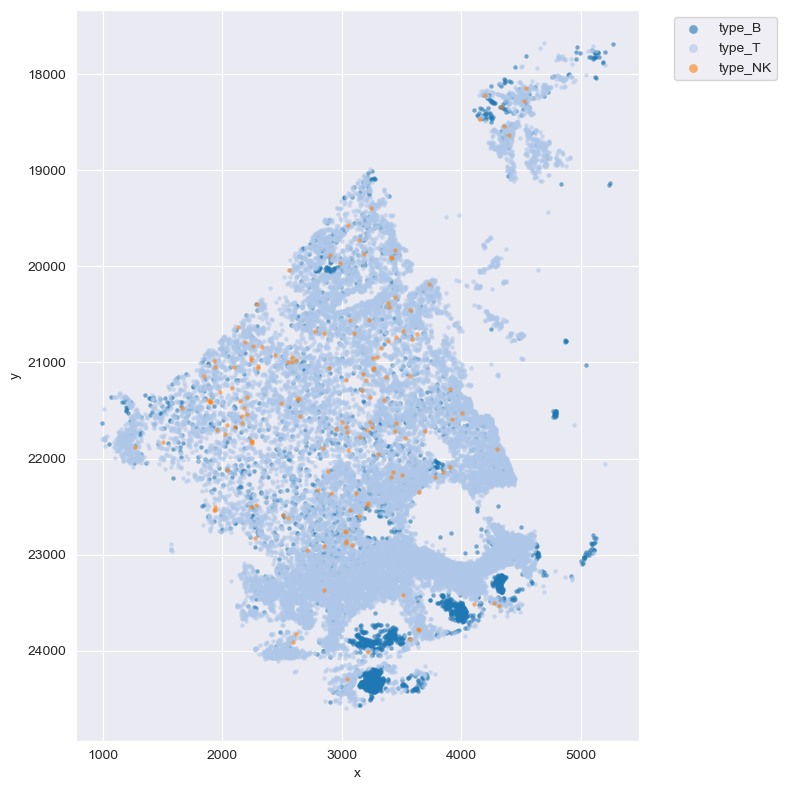

{'type_B': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'type_T': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'type_NK': (1.0, 0.4980392156862745, 0.054901960784313725)}

In [69]:
from scripts.spatial_plot import spatial_celltype_plot

celltype_cols = [c for c in adata.obs.columns if c.startswith("type_") and not c.endswith("unclassified")]

#or use this for all:
#[c for c in adata.obs.columns if c.startswith(("type_", "state_", "subtype_"))]

# Spatial plot
spatial_celltype_plot(adata, celltype_cols, min_cells=100)


In [70]:
print(f"{basename}_subtypes_spatial")

IHOPE14_MedLN_BottomLeft_subtypes_spatial


# Spatial visualization

In [17]:
import scripts
import scripts.spatial_plot
import importlib

importlib.reload(scripts.spatial_plot)

<module 'scripts.spatial_plot' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/spatial_plot.py'>

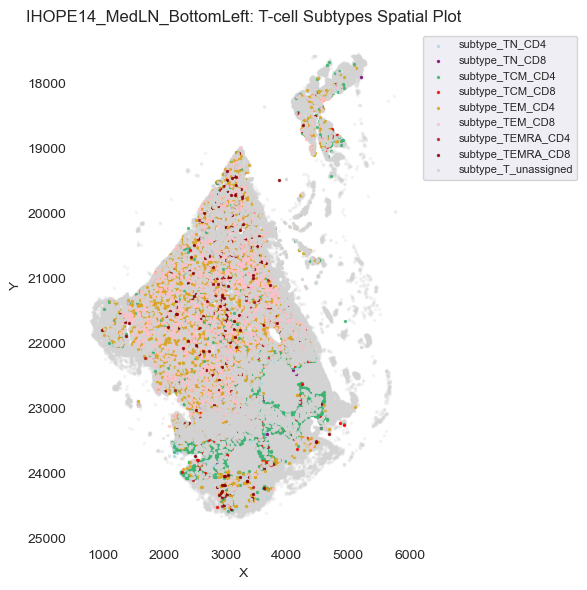

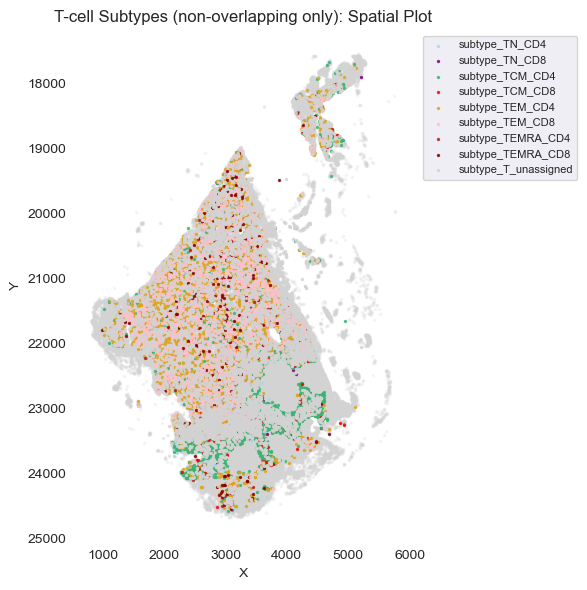

In [71]:
from scripts.spatial_plot import plot_spatial

# List cell types of interest
t_cells = [
    "subtype_TN_CD4",
    "subtype_TN_CD8",
    "subtype_TCM_CD4",
    "subtype_TCM_CD8",
    "subtype_TEM_CD4",
    "subtype_TEM_CD8",
    "subtype_TEMRA_CD4",
    "subtype_TEMRA_CD8",
    "subtype_T_unassigned"]

caption = "T-cell Subtypes"

# Optional colors
tcell_colors = {
    "subtype_TN_CD4": "lightblue",
    "subtype_TN_CD8": "purple",
    "subtype_TCM_CD4": "mediumseagreen",
    "subtype_TCM_CD8": "red",
    "subtype_TEM_CD4": "goldenrod",
    "subtype_TEM_CD8": "pink",
    "subtype_TEMRA_CD4": "firebrick",
    "subtype_TEMRA_CD8": "darkred",
    "subtype_T_unassigned": "lightgrey"
}


# Plot all cells, allowing overlaps
plot_spatial(
    adata,
    celltypes=t_cells,
    colors=tcell_colors,
    size=2,
    alpha=0.8,
    title_prefix=f"{basename}: {caption} "
)

# Plot excluding overlapping cells
plot_spatial(
    adata,
    celltypes=t_cells,
    colors=tcell_colors,
    size=2,
    alpha=0.8,
    exclude_overlaps=True,
    title_prefix=f"{caption} (non-overlapping only): "
)


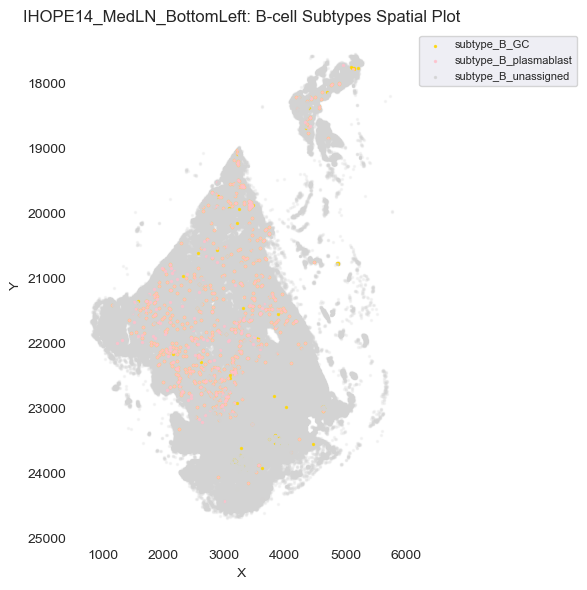

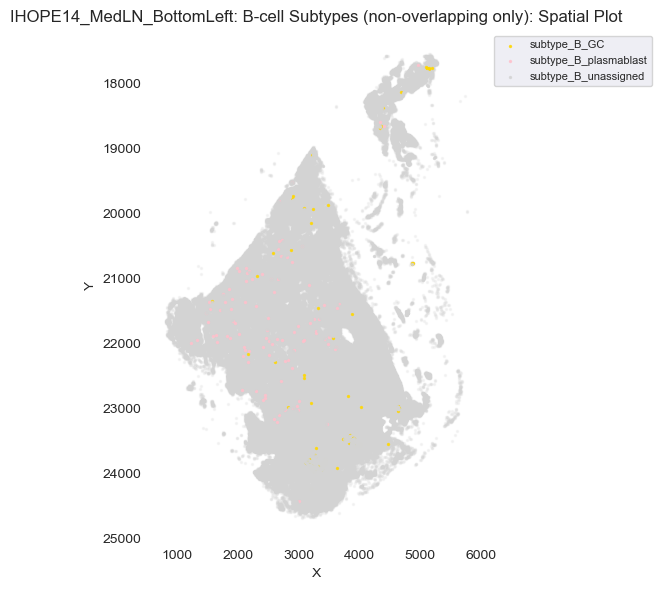

In [79]:
from scripts.spatial_plot import plot_spatial

# B cell subtypes

b_subtypes = [
    "subtype_B_GC",
    "subtype_B_plasmablast",
    "subtype_B_unassigned",
]

caption = "B-cell Subtypes"

b_subtype_colors = {
    "subtype_B_GC": "gold",
    "subtype_B_plasmablast": "pink",
    "subtype_B_unassigned": "lightgrey",
}

# Plot all cells, allowing overlaps
plot_spatial(
    adata,
    celltypes=b_subtypes,
    colors=b_subtype_colors,
    size=2,
    alpha=0.8,
    title_prefix=f"{basename}: {caption} "
)

# Plot excluding overlapping cells
plot_spatial(
    adata,
    celltypes=b_subtypes,
    colors=b_subtype_colors,
    size=2,
    alpha=0.8,
    exclude_overlaps=True,
    title_prefix=f"{basename}: {caption} (non-overlapping only): "
)


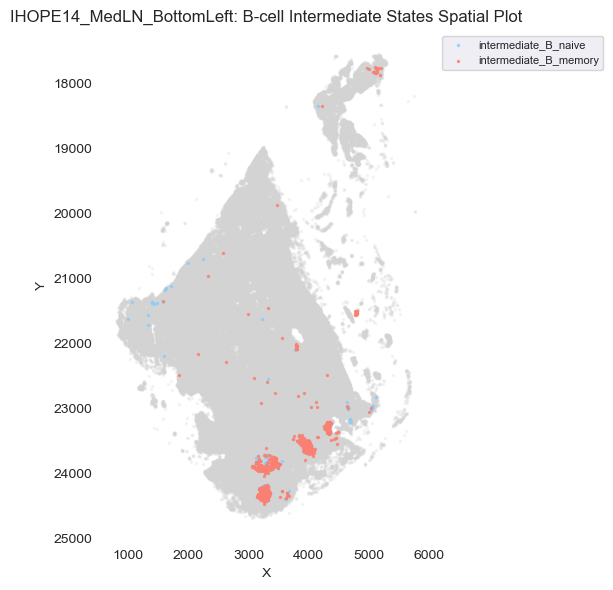

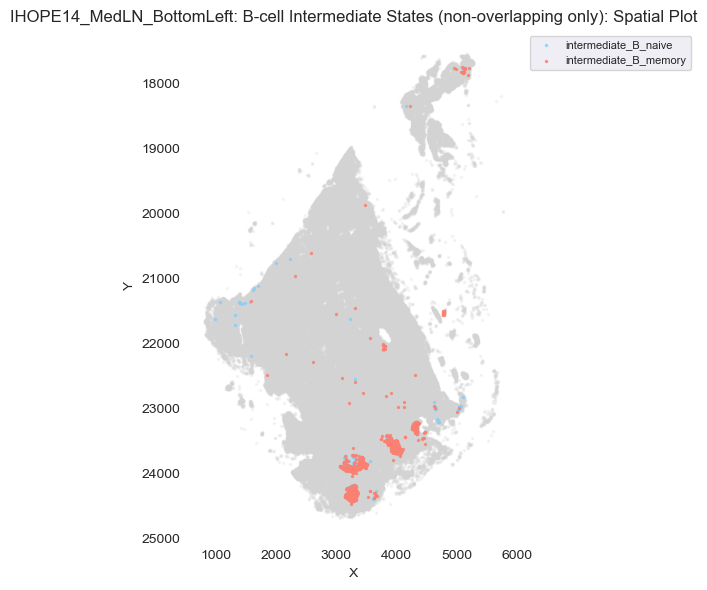

In [78]:
from scripts.spatial_plot import plot_spatial

# B-cell intermediate states (CD27 naïve vs memory)

b_intermediate = [
    "intermediate_B_naive",
    "intermediate_B_memory",
]

caption = "B-cell Intermediate States"

b_intermediate_colors = {
    "intermediate_B_naive": "lightskyblue",
    "intermediate_B_memory": "salmon",
}

# Plot all cells, allowing overlaps
plot_spatial(
    adata,
    celltypes=b_intermediate,
    colors=b_intermediate_colors,
    size=2,
    alpha=0.8,
    title_prefix=f"{basename}: {caption} "
)

# Plot excluding overlapping cells
plot_spatial(
    adata,
    celltypes=b_intermediate,
    colors=b_intermediate_colors,
    size=2,
    alpha=0.8,
    exclude_overlaps=True,
    title_prefix=f"{basename}: {caption} (non-overlapping only): "
)

# Cell type summary in sample

Use after loading data and running annotation!

This will be used later for statistical comparison between tissues.

In [279]:
import scripts
import scripts.summary_celltypes_IHOPE
import importlib

importlib.reload(scripts.summary_celltypes_IHOPE)

<module 'scripts.summary_celltypes_IHOPE' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/summary_celltypes_IHOPE.py'>

In [355]:
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE

df_summary = summarize_celltypes_IHOPE(
    adata,
    filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary.csv"
)


Cell type summary written to:
  /Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/results/reports/celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_summary.csv

Cell type summary:
  level             cell_type                      column  n_cells  pct_total  total_cells
  state              T_memory              state_T_memory     9730       16.3        59774
  state  B_CD27neg_naive_like  state_B_CD27neg_naive_like     9333       15.6        59774
  state B_CD27pos_memory_like state_B_CD27pos_memory_like     5919        9.9        59774
  state               T_naive               state_T_naive     3083        5.2        59774
  state    B_plasmablast_like    state_B_plasmablast_like      685        1.1        59774
  state             B_GC_like             state_B_GC_like      382        0.6        59774
  state             B_resting             state_B_resting      102        0.2        59774
subtype          B_unassigned        subtype_B_unassigned    14123 

# Comparison

Time to compare between samples!

In [88]:
import importlib
import scripts.comparison as comparison

importlib.reload(comparison)

from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
)



Cell type percentage summary (% of total cells):

sample                         IHOPE20_LN  IHOPE26_LN  IHOPE27_LN  IHOPE39_LN
level   cell_type                                                            
state   B_CD27neg_naive_like          0.9        17.8         3.2         0.6
        B_CD27pos_memory_like        30.9        12.5         4.1        25.6
        B_GC_like                     0.3         0.1         0.0         0.3
        B_plasmablast_like            0.5         1.0         1.1         0.8
        B_resting                     0.0         0.0         0.0         0.0
        T_memory                     16.6        22.8        10.3        31.0
        T_naive                      26.5         7.2        36.8        22.5
subtype B_GC_like                     0.3         0.1         0.0         0.3
        B_memory_like                 0.0         0.0         0.0         0.0
        B_naive_like                  0.0         0.0         0.0         0.0
        B_pla

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/comparison.py:160: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.show()


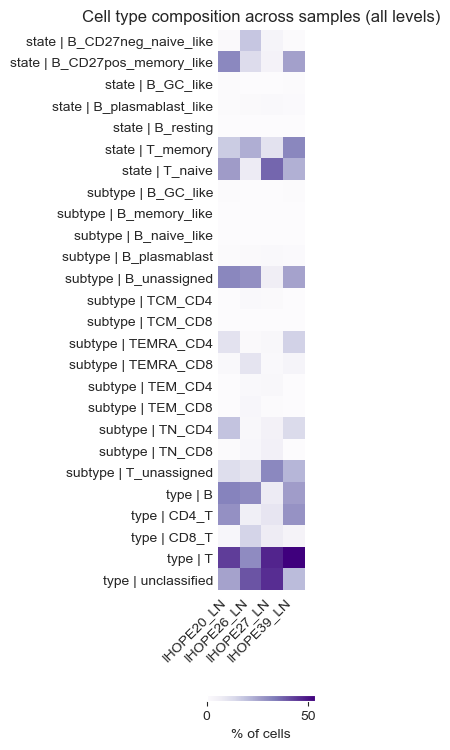

In [89]:
df = load_celltype_summaries(
    summaries_dir=summaries_dir,
    basenames=basenames,
)

print_numeric_summary(df)

matrix = pivot_for_heatmap(df)

plot_celltype_heatmap(
    matrix,
    title="Cell type composition across samples (all levels)",
)


# BANKSY
For this part you need a saved .h5ad file containing an anndata object, and Python 12 is required (not a later version of Python). Note that BANKSY only identifies spatial domains and not cell types. This section provides the workflow from AnnData object to BANKSY domains, which can be used as a foundation for further analysis.

In [242]:
basename = "IHOPE39_MesLN_1"

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/banksy/cluster_methods.py:24: UserWarning: 
No rpy2 installed. BANKSY will run, but mclust will not work.
Note: you can still use the default leiden option for clustering.
Install rpy2 and R in your conda environment if you want to use mclust for clustering.

  warnings.warn(warn_str)
/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Median distance to closest cell = 6.989277502001307

---- Ran median_dist_to_nearest_neighbour in 0.93 s ----

---- Ran generate_spatial_distance_graph in 2.12 s ----

---- Ran row_normalize in 0.48 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 6.63 s ----

----- Plotting Edge Histograms for m = 0 -----

Edge weights (distances between cells): median = 14.918780110989056, mode = 9.782898607644228

---- Ran plot_edge_histogram in 0.14 s ----


Edge weights (weights between cells): median = 0.05836006462443174, mode = 0.03275129487249155

---- Ran plot_edge_histogram in 0.13 s ----

---- Ran generate_spatial_distance_graph in 3.02 s ----

---- Ran theta_from_spatial_graph in 1.40 s ----

---- Ran row_normalize in 0.49 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 9.59 s ----

----- Plotting Edge Histograms for m = 1 -----

Edge weights (distances between cells): median = 20.806008747474124, mode = 19.34143144099699

---- Ran plot_edge_histogram in 0.22 s ----

---- R

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/numpy/lib/histograms.py:841: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)


IndexError: index 101 is out of bounds for axis 0 with size 101

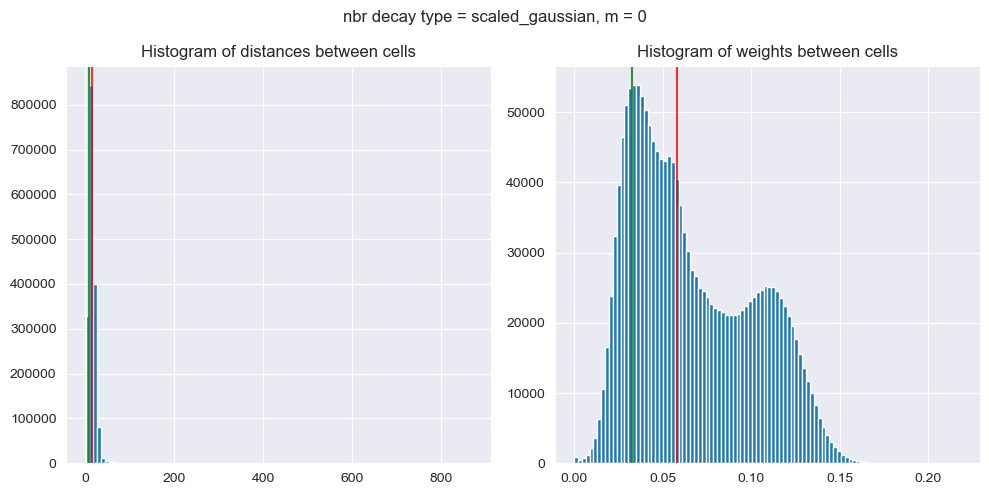

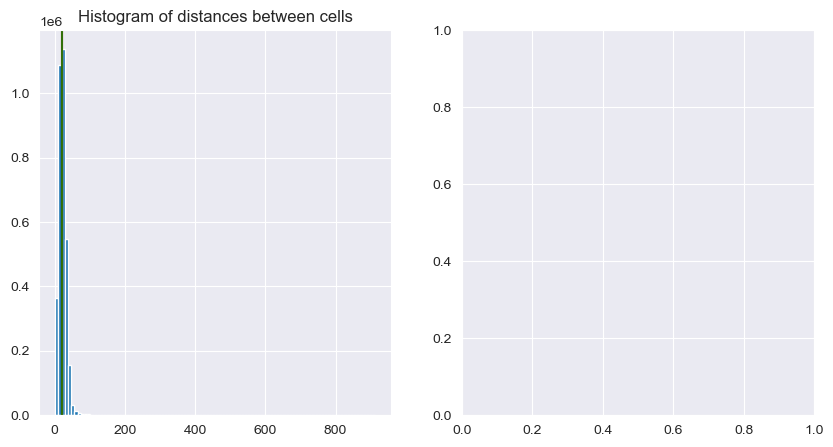

In [25]:
from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam
import scanpy as sc

h5ad_file = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes.h5ad"

# Load your spatial transcriptomics data
adata = sc.read_h5ad(h5ad_file)

# Initialize BANKSY
coord_keys = ('x', 'y', 'spatial')
banksy_dict = initialize_banksy(
    adata,
    coord_keys=coord_keys,
    num_neighbours=15,
    nbr_weight_decay='scaled_gaussian'
)

# Run BANKSY clustering

results_df = run_banksy_multiparam(
    adata,
    banksy_dict,
    lambda_list=[0.2],
    resolutions=[0.5, 1.0]
)


Median distance to closest cell = 6.989277502001307

---- Ran median_dist_to_nearest_neighbour in 2.27 s ----


Median distance to closest cell = 6.989277502001307

---- Ran median_dist_to_nearest_neighbour in 2.93 s ----

---- Ran generate_spatial_distance_graph in 2.86 s ----

---- Ran row_normalize in 0.49 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 9.94 s ----

---- Ran generate_spatial_distance_graph in 2.79 s ----

---- Ran theta_from_spatial_graph in 1.39 s ----

---- Ran row_normalize in 0.49 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 13.70 s ----

----- Plotting Weights Graph -----
Maximum weight: 0.21834196581661036

---- Ran plot_graph_weights in 39.74 s ----

Maximum weight: (0.09076966554277836-0.007179521438041436j)

---- Ran plot_graph_weights in 63.70 s ----

Runtime Feb-26-2026-11-44

38 genes to be analysed:
Gene List:
Index(['arcsinh_cf5.0_CCR6', 'arcsinh_cf5.0_CCR7', 'arcsinh_cf5.0_CD107a',
       'arcsinh_cf5.0_CD11c', 'arcsinh_cf5.0_CD14'

Error processing line 1 of /Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site.py", line 195, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


UMAP embedding
------------------------------------------------------------
shape: (112174, 2)


AxisArrays with keys: reduced_pc_20, reduced_pc_20_umap
Decay type: scaled_gaussian
Neighbourhood Contribution (Lambda Parameter): 0.8
reduced_pc_20 

reduced_pc_20_umap 

PCA dims to analyse: [20]

Setting up partitioner for (nbr decay = scaled_gaussian), Neighbourhood contribution = 0.8, PCA dimensions = 20)


Nearest-neighbour weighted graph (dtype: float64, shape: (112174, 112174)) has 5608700 nonzero entries.
---- Ran find_nn in 615.62 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (112174, 112174)) has 5608700 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 118692092 to 5596996.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (112174, 112174)) has 5174276 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (11217

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/banksy/labels.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  expand_labels(label_list[sort_indices[0]],


,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,relabeled
scaled_gaussian_pc20_nc0.80_r0.50,scaled_gaussian,0.8,20,0.5,13,"Label object:\nNumber of labels: 13, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 13, number of..."


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_52270/2008403914.py:67: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')


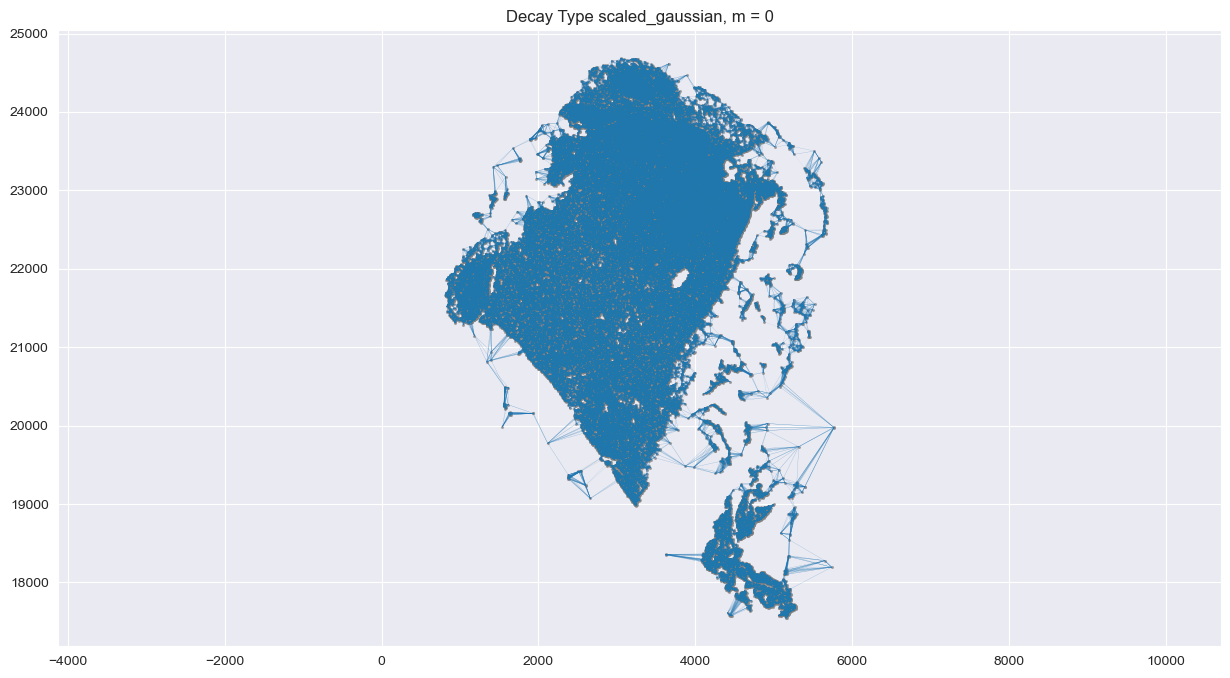

/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/matplotlib/collections.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  renderer.draw_path_collection(


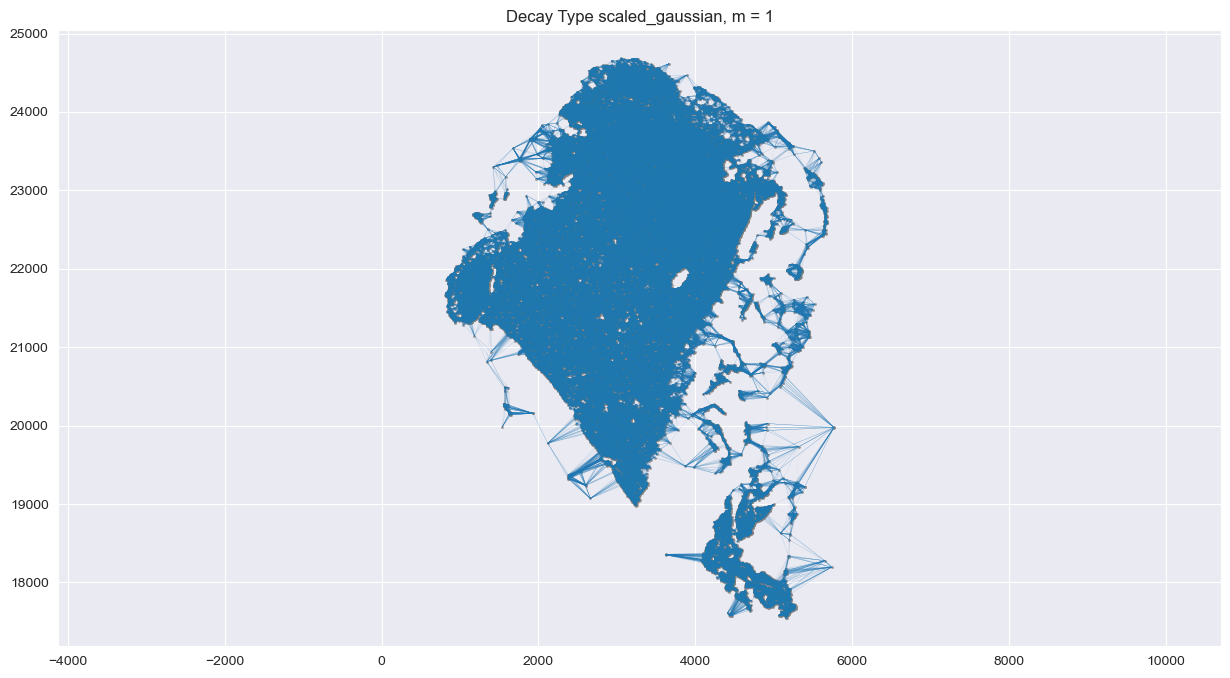

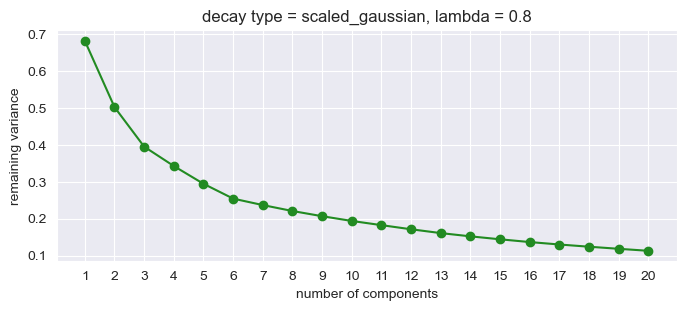

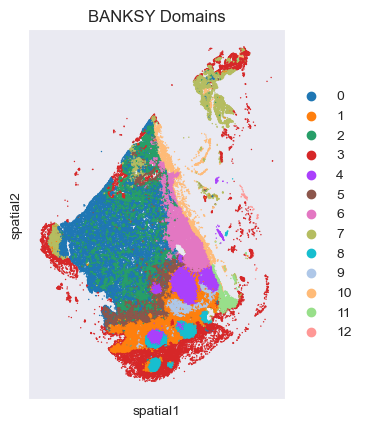

BANKSY clustering complete for IHOPE14_MedLN_BottomLeft! Domains added to `adata.obs['banksy_domain']`


In [26]:
from banksy.main import median_dist_to_nearest_neighbour
from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix
from banksy_utils.umap_pca import pca_umap
from banksy.cluster_methods import run_Leiden_partition
from banksy.plot_banksy import plot_results

# Parameters for BANKSY
coord_keys = ('x', 'y', 'spatial')
k_geom = 15
max_m = 1
nbr_weight_decay = "scaled_gaussian"
lambda_list = [0.8]
resolutions = [0.5]       # Leiden clustering resolution
pca_dims = [20]             # Try a lower number?
cluster_algorithm = 'leiden'
cmap = 'tab20'             # color map for spatial plotting
save_path = None           # e.g., "./BANKSY_results" if you want to save figures

# Compute neighbor distances
nbrs = median_dist_to_nearest_neighbour(adata, key=coord_keys[2])

# Initialize BANKSY
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=False,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=False
)

# Generate BANKSY matrix
banksy_dict, banksy_matrix = generate_banksy_matrix(
    adata,
    banksy_dict,
    lambda_list,
    max_m
)

# Dimensionality reduction by UMAP
pca_umap(
    banksy_dict,
    pca_dims=pca_dims,
    add_umap=True
)

# Run Leiden clustering
results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions=resolutions,
    num_nn=50,
    num_iterations=-1,
    partition_seed=1234,
    match_labels=True,
    max_labels=None
)

# Map clusters back to adata
cluster_labels = results_df.labels[results_df.index[0]].dense
adata.obs['banksy_domain'] = cluster_labels.astype(str)

# Optional: visualize
sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')

# Optional: use BANKSY plotting function
if save_path is not None:
    os.makedirs(save_path, exist_ok=True)
    weights_graph = banksy_dict['scaled_gaussian']['weights'][1]
    plot_results(
        results_df[results_df['num_labels']==len(np.unique(cluster_labels))],
        weights_graph,
        cmap,
        match_labels=True,
        coord_keys=coord_keys,
        max_num_labels=max_num_labels,
        save_path=save_path,
        save_fig=True,
        save_fullfig=True,
        dataset_name='Sample',
        save_labels=True
    )

print(f"BANKSY complete for {basename}! Domains added to `adata.obs['banksy_domain']`")

Save anndata object with BANKSY domains

In [27]:
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_banksy.h5ad"
save_h5ad(adata, h5adpath)

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_19913/3608005373.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(adata.obs[cluster_key])


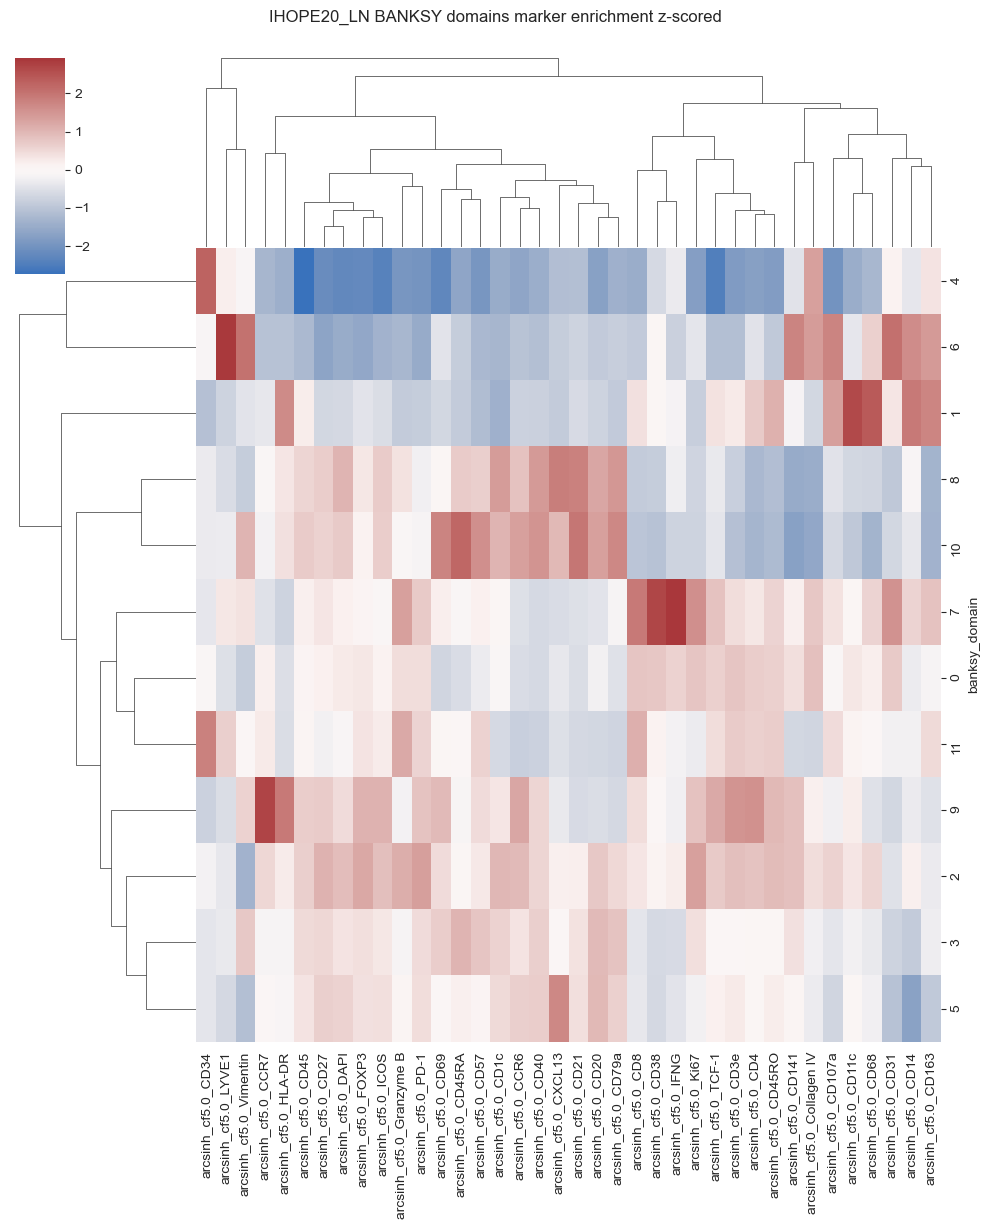

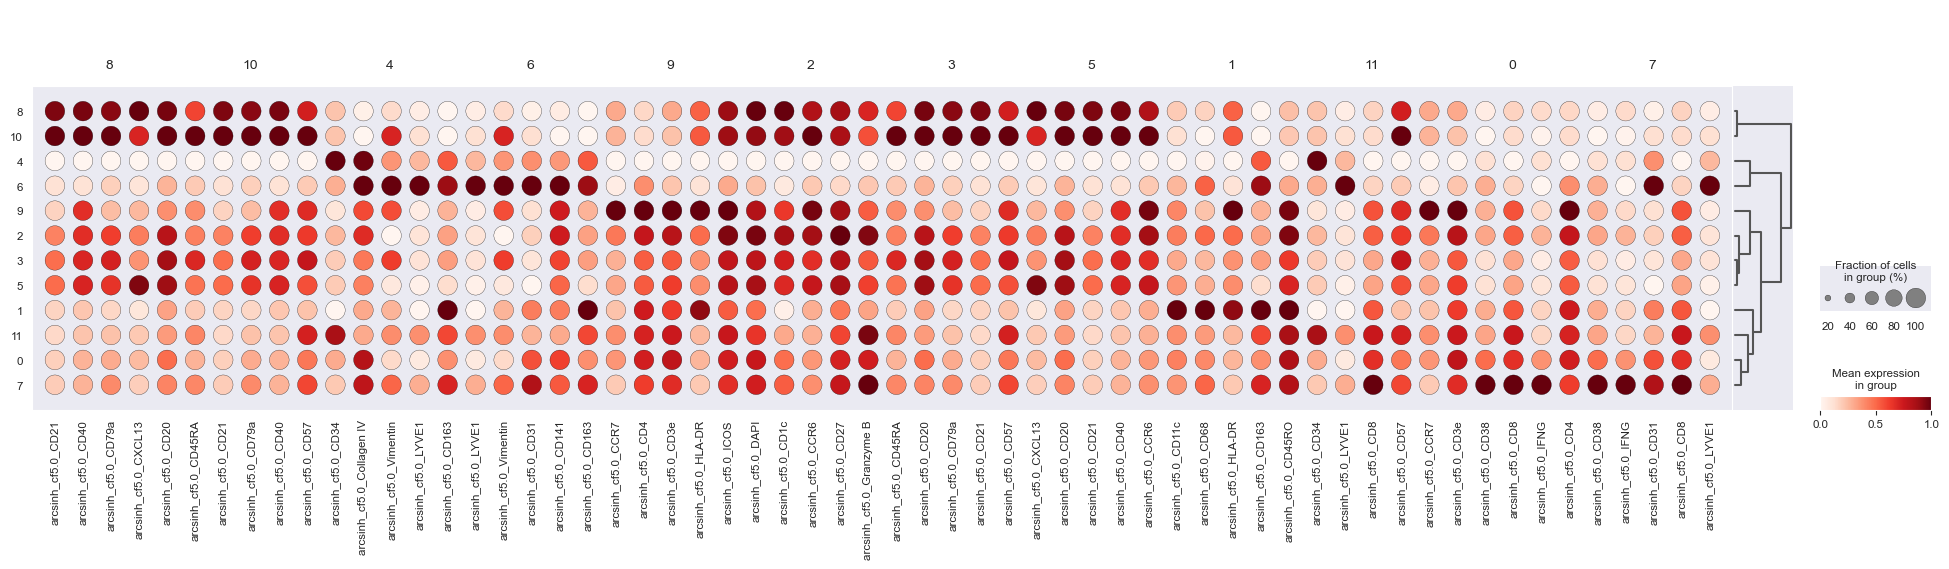

In [108]:
# Deciphering cluster identity!

cluster_key = "banksy_domain"

# Clusterwise mean intensity heatmap:
#Mean expression per domain
cluster_means = (
    pd.DataFrame(
        adata.X,
        index=adata.obs_names,
        columns=adata.var_names
    )
    .groupby(adata.obs[cluster_key])
    .mean()
)

# Z-score across clusters
cluster_means_z = cluster_means.sub(cluster_means.mean(), axis=1)
cluster_means_z = cluster_means_z.div(cluster_means.std(), axis=1)

#Heatmap z-scored
sns.clustermap(
    cluster_means_z,
    cmap="vlag",
    center=0,
    figsize=(10, 12),
    col_cluster=True,
    row_cluster=True
)
plt.suptitle(f"{basename} BANKSY domains marker enrichment z-scored", y=1.02)
plt.show()

# Rows = BANKSY domains
# Columns = markers
# Red = enriched, Blue = depleted
# GC domains should light up for CD20, CD21, CD38, CXCL13
# T zones for CD3e, CD4, CD8
# Sinus / stroma for LYVE1, Vimentin, Collagen IV

# Step 2: differential analysis
# Rank markers per BANKSY domain –nonparametric test to compare markers in domain vs all other cells
# logFC = log( mean(M in D) / mean(M outside D) )
# Also the p-values are FDR-adjusted by default.
sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    method="wilcoxon"
)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    groupby=cluster_key,
    standard_scale="var"
)

# Dot size = fraction of cells in domain expressing marker (but all are above 0, hence same size)
# Color = average intensity

# B-cell follicle identification

Identify B-cell enriched domains and the cell types that require BANKSY information

In [201]:
import importlib
import scripts.banksy_domains

# Reload the module after editing
importlib.reload(scripts.banksy_domains)

<module 'scripts.banksy_domains' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py'>

In [44]:
# Identify follicles (once per BANKSY run)
from scripts.banksy_domains import identify_bcell_follicles

min_fraction_b = 0.16

adata, follicle_stats = identify_bcell_follicles(
    adata,
    banksy_domain_key="banksy_domain",
    min_fraction_bcells= min_fraction_b,
)

Identified 1 B-cell–enriched domains (≥16% B cells)


/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/banksy_domains.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


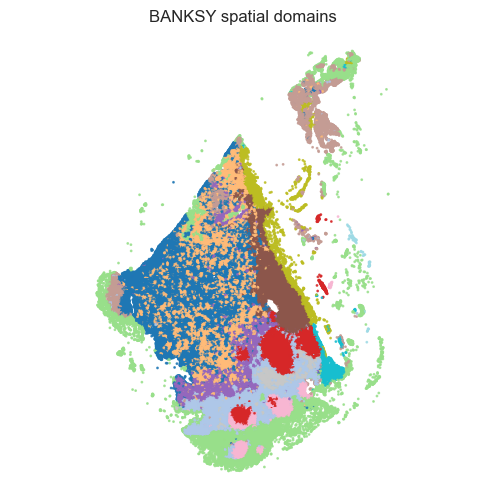

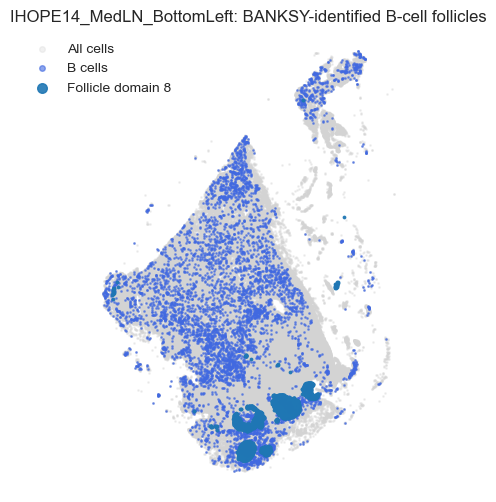

In [45]:
from scripts.banksy_domains import plot_banksy_domains, plot_bcell_follicles

plot_banksy_domains(adata)
plot_bcell_follicles(adata, sample_name = basename)

Named figs as:

In [46]:
print(f"{basename}_BANKSY_Bcell_minfrac{min_fraction_b}_domains.png")

IHOPE14_MedLN_BottomLeft_BANKSY_Bcell_minfrac0.16_domains.png


In [295]:
import importlib
import scripts.celltype_rules_IHOPE
importlib.reload(scripts.celltype_rules_IHOPE)


<module 'scripts.celltype_rules_IHOPE' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/celltype_rules_IHOPE.py'>

TfH-like cells: 1999 (1.78% of all cells)


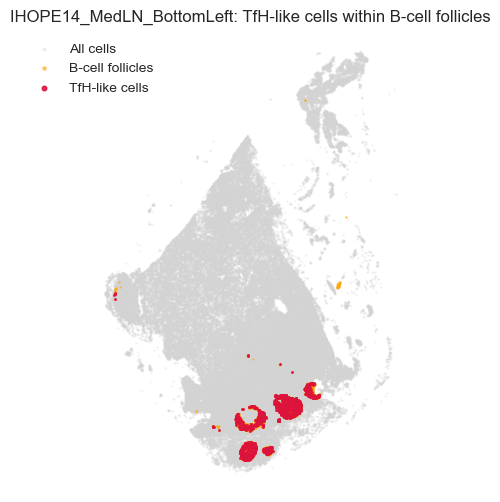

In [47]:
# Add TfH-like cells
from scripts.celltype_rules_IHOPE import add_TfH_like_cells

adata = add_TfH_like_cells(
    adata,
    follicle_key="B_follicle",
    plot=True,
    size=0.3,
    sample_name = basename
)


Named as:

In [49]:
print(f"{basename}_TfH_spatial_min{min_fraction_b}fracBc")

IHOPE14_MedLN_BottomLeft_TfH_spatial_min0.16fracBc


Finally, save the updated anndata object with the TfH cells added.

In [50]:
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_banksy_TfH.h5ad"
save_h5ad(adata, h5adpath)

New cell type summary

In [51]:
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE

df_summary = summarize_celltypes_IHOPE(
    adata,
    filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary_withTfH.csv"
)


Cell type summary written to:
  /Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/results/reports/celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_summary_withTfH.csv

Cell type summary:
  level             cell_type                      column  n_cells  pct_total  total_cells
  state               T_naive               state_T_naive    45950       41.0       112174
  state              T_memory              state_T_memory    23213       20.7       112174
  state B_CD27pos_memory_like state_B_CD27pos_memory_like     4712        4.2       112174
  state  B_CD27neg_naive_like  state_B_CD27neg_naive_like     3009        2.7       112174
  state    B_plasmablast_like    state_B_plasmablast_like      872        0.8       112174
  state             B_resting             state_B_resting       28        0.0       112174
  state             B_GC_like             state_B_GC_like       24        0.0       112174
subtype          T_unassigned        subtype_T_un